In [1]:
import slangpy as spy
from pyglm import glm
import torch
import torchvision
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

from cs248a_renderer import setup_device, RendererModules
from cs248a_renderer.renderer.core_renderer import Renderer
from cs248a_renderer.model.volumes import DenseVolume
from cs248a_renderer.model.transforms import Transform3D

from cs231nfinal.camera import RandomCameraTransform
from cs231nfinal.tvnorm import tv_image_loss_anisotropic, tv_volume_loss_anisotropic

%load_ext autoreload
%autoreload 2

device = setup_device([])
renderer_modules = RendererModules(device)

[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
# OUTPUT_IMG_SIZE = (800, 800)
PROCESS_IMG_SIZE = (300, 300)
PREVIEW_IMG_SIZE = (500, 500)

# create framebuffers
output_image = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_float,
    usage=spy.TextureUsage.unordered_access,
    width=PROCESS_IMG_SIZE[0],
    height=PROCESS_IMG_SIZE[1],
)

output_preview = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_float,
    usage=spy.TextureUsage.unordered_access,
    width=PREVIEW_IMG_SIZE[0],
    height=PREVIEW_IMG_SIZE[1],
)

# Setup the renderer
renderer = Renderer(
    device=device,
    render_texture=output_image,
    render_modules=renderer_modules
)
renderer.sqrt_spp = 1
renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

preview_renderer = Renderer(
    device=device,
    render_texture=output_preview,
    render_modules=renderer_modules
)
preview_renderer.sqrt_spp = 1
preview_renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

In [3]:
from cs231nfinal.data import DatasetID, DataSet
import numpy as np
from openvdb import FloatGrid

dataset = DataSet.Get(DatasetID.SMOKE_MIDRES)

data_array = np.zeros(dataset.resolution)
grid = dataset.get_grid("density", frame=70, type=FloatGrid)

grid.copyToArray(data_array, ijk=grid.evalLeafBoundingBox()[0])
min, max = grid.evalMinMax()

# normalize data
data_array = 0.5 * ((data_array + min) / (max - min))

CAMERA_POS = glm.vec3(25,0,0)
VOLUME_POS = glm.vec3(0,3,4)

In [4]:
def make_dense_volume(volume_tensor) -> DenseVolume:
    return DenseVolume(
        name="volume",
        transform=Transform3D(position=VOLUME_POS),
        data=volume_tensor.detach().numpy().astype(np.float32),
        properties={
            "pivot": (0.5, 0.5, 0.5),
            "voxel_size": dataset.voxel_size,
        },
    )

def show_preview(dense_volume, cam_mat, fov):
    preview_renderer.load_volume(volume=dense_volume)
    preview_renderer.render(cam_mat, fov)
    preview_res = np.flipud(output_preview.to_numpy().copy())
    plt.imshow(preview_res, cmap="gray")
    plt.axis("off")
    plt.show()

In [5]:
cam_transform = RandomCameraTransform(CAMERA_POS, sigma=1.0)
fov = 40

canonical_cam = next(RandomCameraTransform(CAMERA_POS, sigma=0))

In [6]:

_resize_transform = torchvision.transforms.Resize(PROCESS_IMG_SIZE)
_grayscale_transform = torchvision.transforms.Grayscale()
prep_style = lambda t: _grayscale_transform(_resize_transform(t)).squeeze()

style_img = prep_style(torchvision.io.read_image("data/style/good_ones/dark_matter_bw.png") / 255)

Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

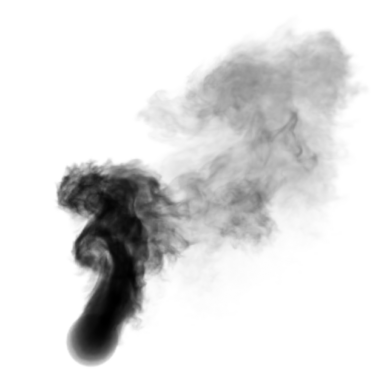

Views:   0%|          | 0/6 [00:00<?, ?it/s]

[WARN] (rhi) slang: metal 32023.850: /Users/milner/Documents/VSCode/CS231N/final-project/.venv/lib/python3.13/site-packages/cs248a_renderer/slang_shaders/./texture/diff_texture.slang(364): warning :  unused variable '_S122' [-Wunused-variable]
    float _S122 = atomic_fetch_add_explicit(&(*(diffTexPair_differential_dTex_0+(_S96 + _S97)))[int(0)], _S111 * wz0_0 * dOut_0, memory_order_relaxed);
          ^
metal 32023.850: /Users/milner/Documents/VSCode/CS231N/final-project/.venv/lib/python3.13/site-packages/cs248a_renderer/slang_shaders/./texture/diff_texture.slang(365): warning :  unused variable '_S123' [-Wunused-variable]
    float _S123 = atomic_fetch_add_explicit(&(*(diffTexPair_differential_dTex_0+_S106))[int(0)], _S118 * dOut_0, memory_order_relaxed);
          ^
metal 32023.850: /Users/milner/Documents/VSCode/CS231N/final-project/.venv/lib/python3.13/site-packages/cs248a_renderer/slang_shaders/./texture/diff_texture.slang(366): warning :  unused variable '_S124' [-Wunused-variab

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

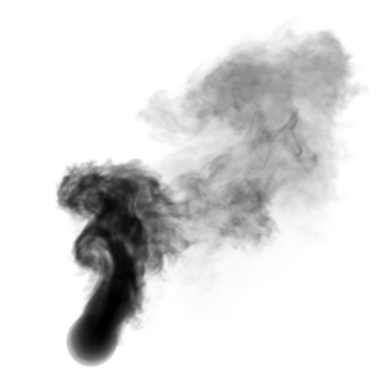

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

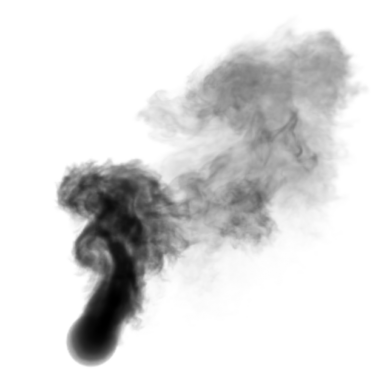

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

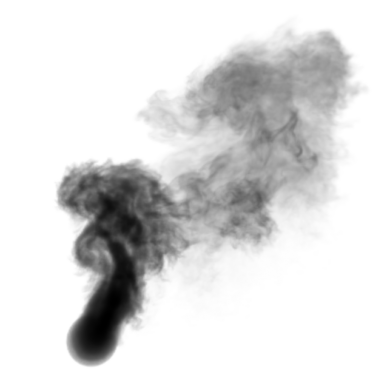

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

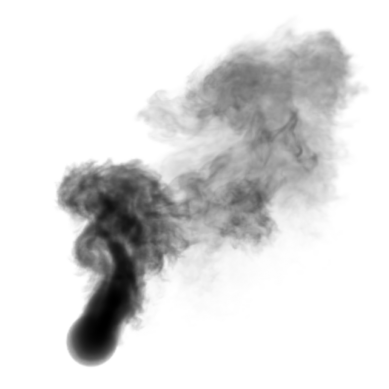

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

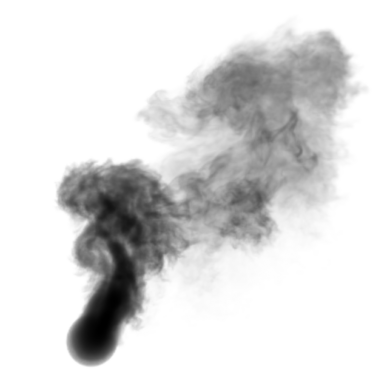

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

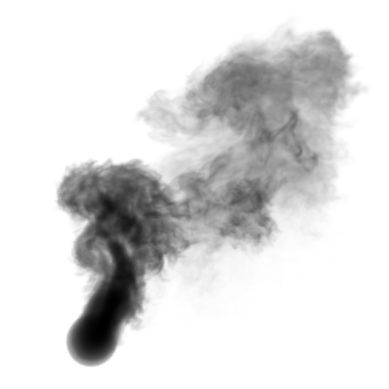

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

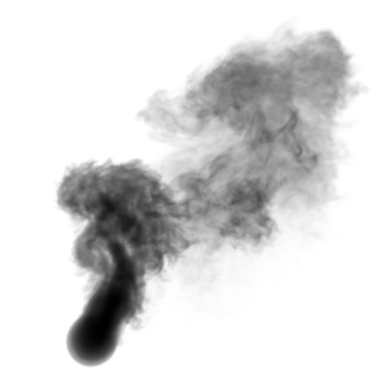

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

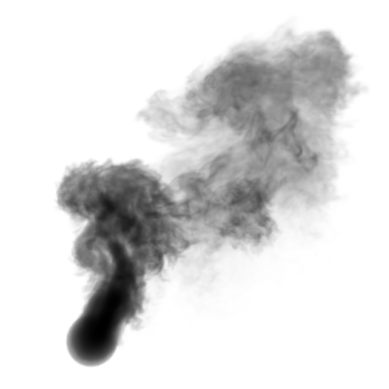

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

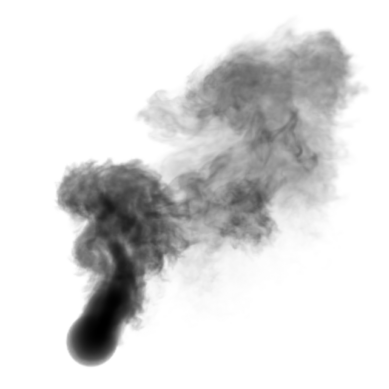

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

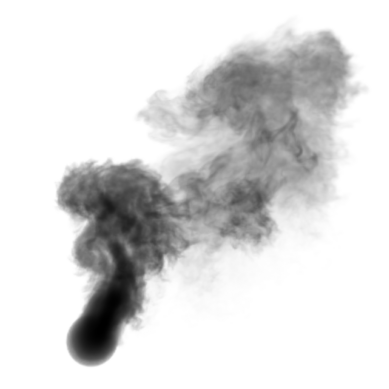

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

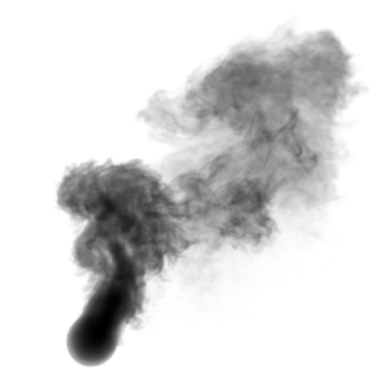

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

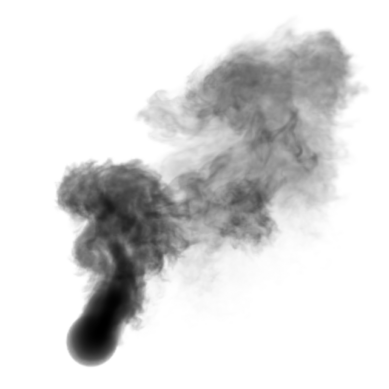

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

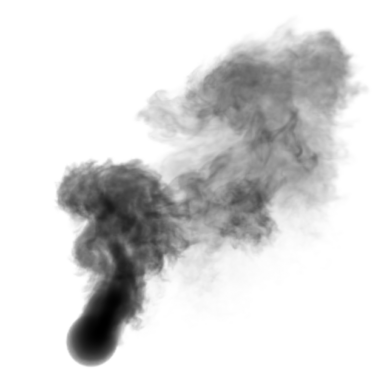

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

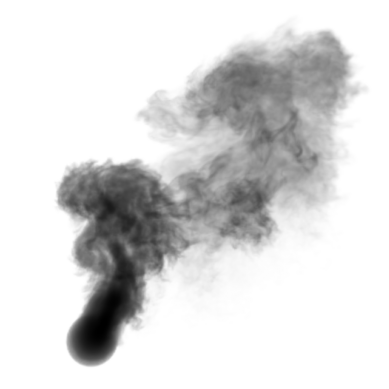

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

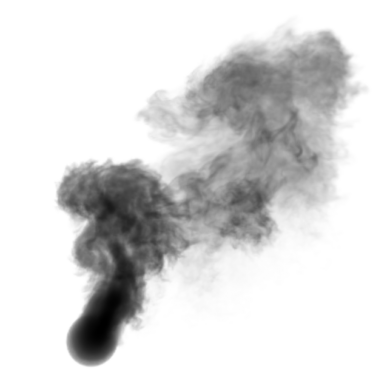

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

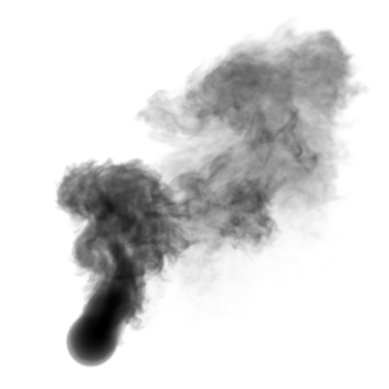

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

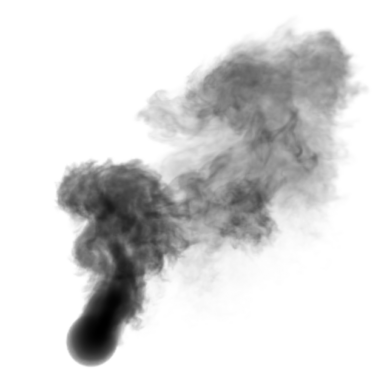

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

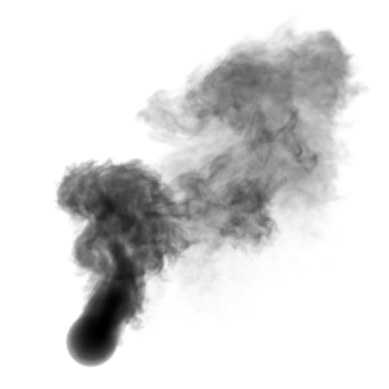

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

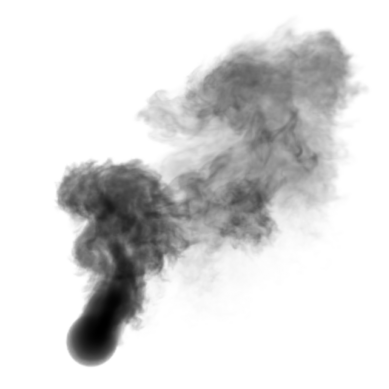

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

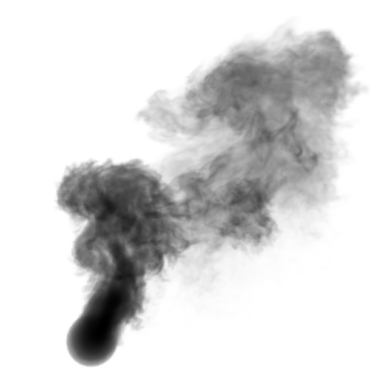

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

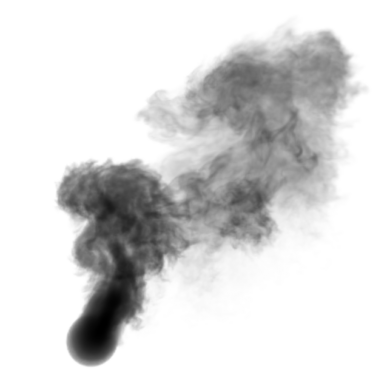

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

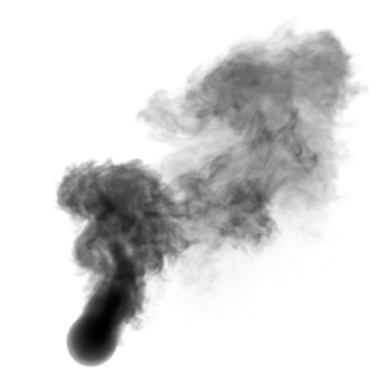

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

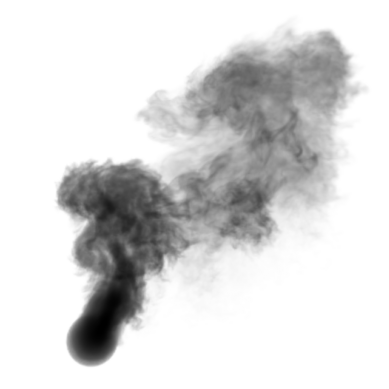

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

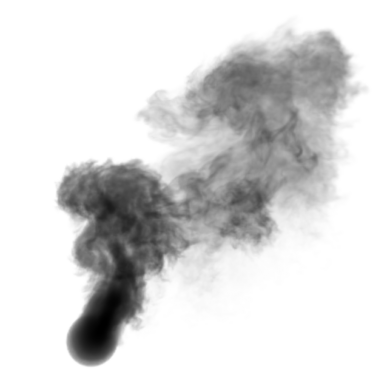

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

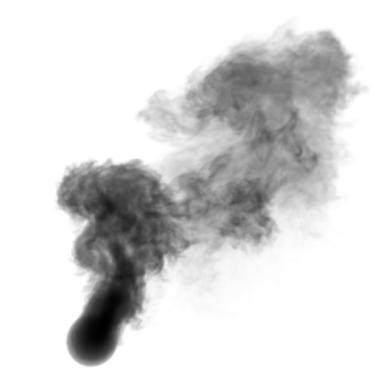

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

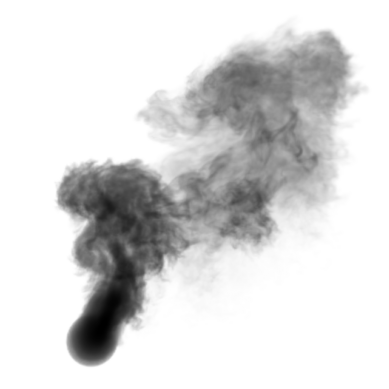

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

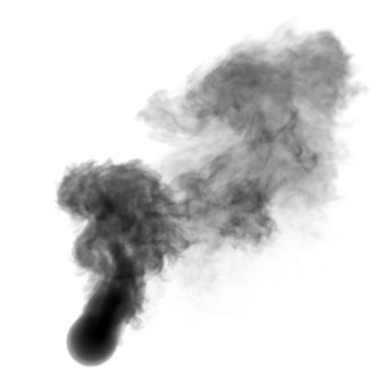

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

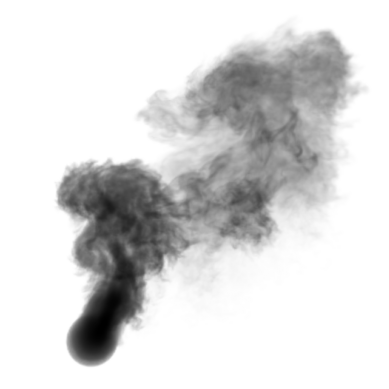

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

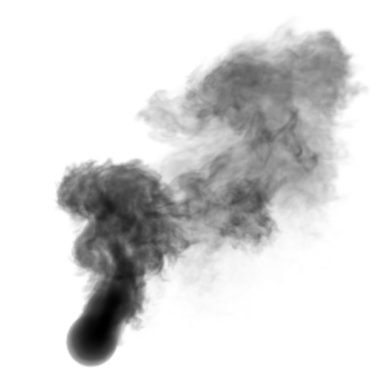

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

Views:   0%|          | 0/6 [00:00<?, ?it/s]

In [7]:
num_epochs = 150
num_views = 6
learning_rate = 5e-2
# tv_weight_2d = 0.001
tv_weight_2d = 0
tv_weight_3d = 0.007

input_tensor = torch.tensor(data_array.astype(np.float32), requires_grad=False)
input_density_total = input_tensor.sum()

batch_losses = []

density_gain = torch.ones_like(input_tensor, requires_grad=True)

optim = torch.optim.Adam([density_gain], lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, 0.99)

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    optim.zero_grad()

    # preserve density
    scaled_input = input_tensor * density_gain
    density_normalized_input = scaled_input * (input_density_total / scaled_input.sum())
    dense_volume = make_dense_volume(density_normalized_input)

    renderer.load_volume(volume=dense_volume)

    if (epoch % 5) == 0:
        show_preview(dense_volume, canonical_cam, fov)

    gain_acc = np.zeros(input_tensor.shape).astype(np.float32)


    batch_loss = 0
    for i in tqdm(range(num_views), desc="Views"):

        view_mat = next(cam_transform)

        renderer.render(view_mat, fov)

        volume_render = torch.tensor(np.flipud(output_image.to_numpy()).copy(), requires_grad=True)

        stylization = style_img.detach().clone()


        # plt.imshow(volume_render.detach().numpy(), cmap="gray")
        # plt.xlabel(f"Current vol; epoch: {epoch}, view: {i}")
        # plt.show()
        # plt.imshow(stylization.detach().numpy(), cmap="gray")
        # plt.xlabel(f"Masked Style; epoch: {epoch}, view: {i}")
        # plt.show()
        
        loss_fn = torch.nn.MSELoss()
        loss = loss_fn(volume_render, stylization) + tv_weight_2d * tv_image_loss_anisotropic(volume_render)
        batch_loss += loss.item()

        loss.backward()

        # plt.imshow(volume_render.grad.detach().numpy())
        # plt.xlabel(f"Image Gradient; epoch: {epoch}, view: {i}")
        # plt.colorbar()
        # plt.show()

        renderer.render_volume_backward(
            view_mat=view_mat, 
            fov=fov, 
            out_grad=torch.flipud(volume_render.grad)
        )
        d_volume = renderer.get_d_volume().reshape(input_tensor.shape)
        gain_acc += d_volume

    tv_loss = tv_weight_3d * tv_volume_loss_anisotropic(density_normalized_input)
    tv_loss.backward()
    
    with torch.no_grad():
        density_gain.grad = density_gain.grad + torch.tensor(gain_acc) / input_tensor
    
    optim.step()

    with torch.no_grad():
        density_gain.clamp_(0, 100)
    
    batch_losses.append(batch_loss)


    scheduler.step()



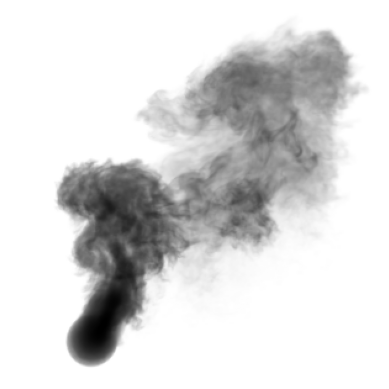

In [8]:
renderer.render(canonical_cam, fov)

volume_render = torch.tensor(np.flipud(output_image.to_numpy()).copy(), requires_grad=True)
plt.imshow(volume_render.detach().numpy(), cmap="gray")
plt.axis("off")
plt.show()

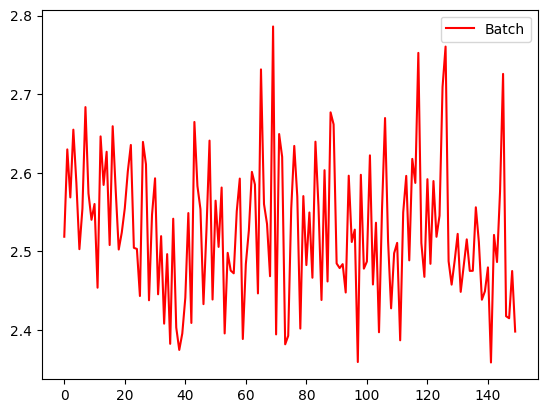

In [10]:
x = range(num_epochs)
plt.plot(x, batch_losses, label="Batch", color="red")
# plt.yscale("log")
plt.legend()
plt.show()